<a href="https://colab.research.google.com/github/alfiahlutfi/RegresiLinear_Kelas5B_Kelompok6/blob/main/RegresiLinear_Kelas5B_Kelompok6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle

In [2]:
import os
import getpass

print("API Token Kaggle: ")
kaggle_token = getpass.getpass('KAGGLE_API_TOKEN: ')

os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("\nOtentifikasi API Kaggle Selesai!")

API Token Kaggle: 
KAGGLE_API_TOKEN: ··········

Otentifikasi API Kaggle Selesai!


In [3]:
print("Mengunduh dataset Vehicle...")
!kaggle datasets download -d nehalbirla/vehicle-dataset-from-cardekho

print("Unduhan Selesai!")

Mengunduh dataset Vehicle...
Dataset URL: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho
License(s): DbCL-1.0
100% 292k/292k [00:00<00:00, 66.4MB/s]

Unduhan Selesai!


In [4]:
!unzip -q vehicle-dataset-from-cardekho.zip -d data_mobil_bekas/

print("Unduhan dan Ekstraksi Selesai!")

Unduhan dan Ekstraksi Selesai!


## Tahap 1 - Memahami Data

In [5]:
import pandas as pd

df = pd.read_csv('data_mobil_bekas/CAR DETAILS FROM CAR DEKHO.csv')

In [6]:
print("--- 5 Baris Pertama Data ---")
display(df.head(10))

# Cek dimensi data (jumlah baris dan kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Cek tipe data setiap kolom dan informasi penggunaan memori
print("\n--- Informasi Dataset (Tipe Data & Non-Null) ---")
df.info()

# Dapatkan nama-nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())

--- 5 Baris Pertama Data ---


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner



Dimensi dataset: 4340 baris, 8 kolom

--- Informasi Dataset (Tipe Data & Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB

--- Daftar Nama Kolom ---
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)


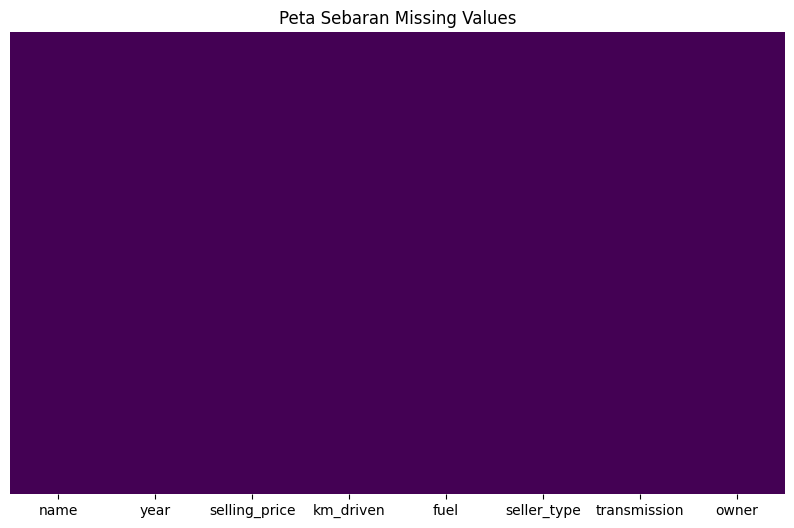


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 763


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3912,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
4016,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
99,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
2578,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
554,Audi A4 3.0 TDI Quattro,2013,1580000,86000,Diesel,Dealer,Automatic,First Owner
...,...,...,...,...,...,...,...,...
2936,Volkswagen Vento 1.5 TDI Highline Plus AT,2017,890000,40219,Diesel,Dealer,Automatic,First Owner
1628,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
3052,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
478,Volkswagen Vento Diesel Highline,2011,300000,65000,Diesel,Individual,Manual,Second Owner


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Jumlah Missing', 'Persentase (%)'])
# Tampilkan hanya kolom yang memiliki missing value
display(missing_table[missing_table['Jumlah Missing'] > 0])

# Visualisasi Missing Values (Menggunakan Heatmap seaborn)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Peta Sebaran Missing Values')
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")
if jumlah_duplikat > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

**Penanganan duplikat**. Baris yang identik (763 baris) dihapus **sekarang**, sebelum EDA dan sebelum pembagian data.
Alasannya: data yang tercatat dua kali bisa masuk ke data latih dan data uji sekaligus, sehingga hasil evaluasi terlihat lebih bagus dari kenyataan.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)

## Tahap 2 - EDA (Exploratory Data Analysis

In [9]:
print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df.describe())

print("\n--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---")
display(df.describe(include='object'))

--- Statistik Deskriptif untuk Kolom Numerik ---


,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000



--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---


,name,fuel,seller_type,transmission,owner
count,3577,3577,3577,3577,3577
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,54,1800,2832,3265,2218


--- Analisis Univariat untuk Kolom Numerik


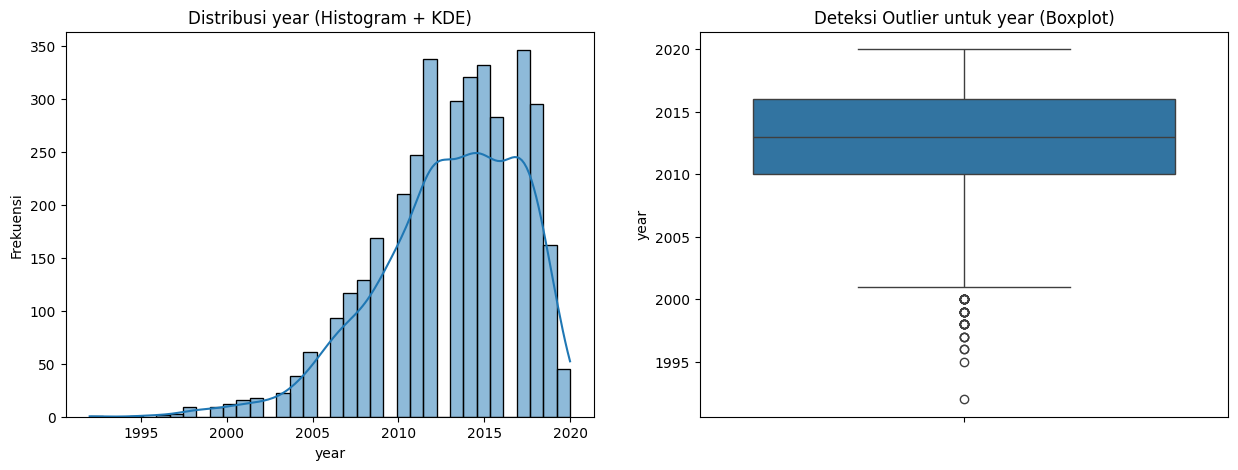

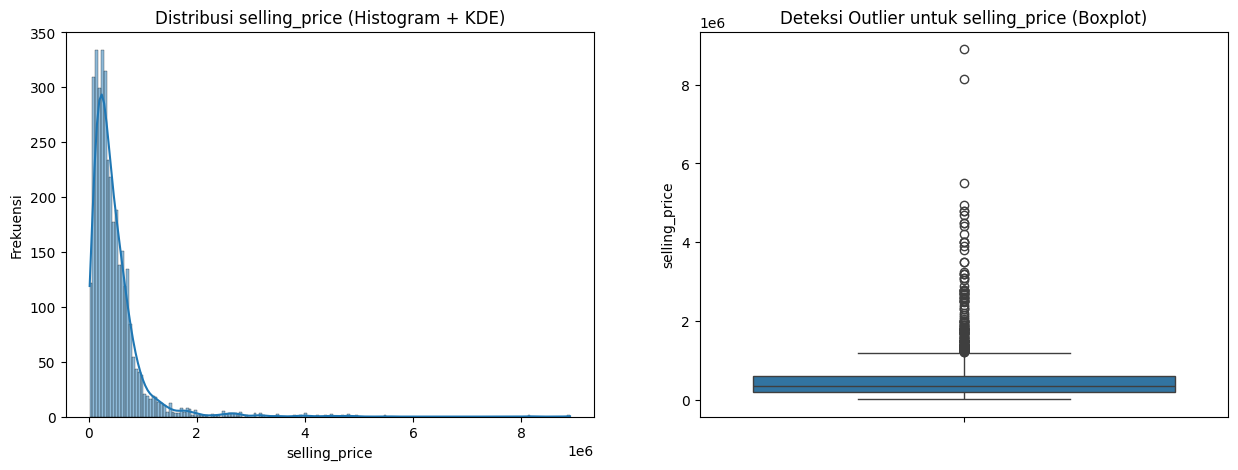

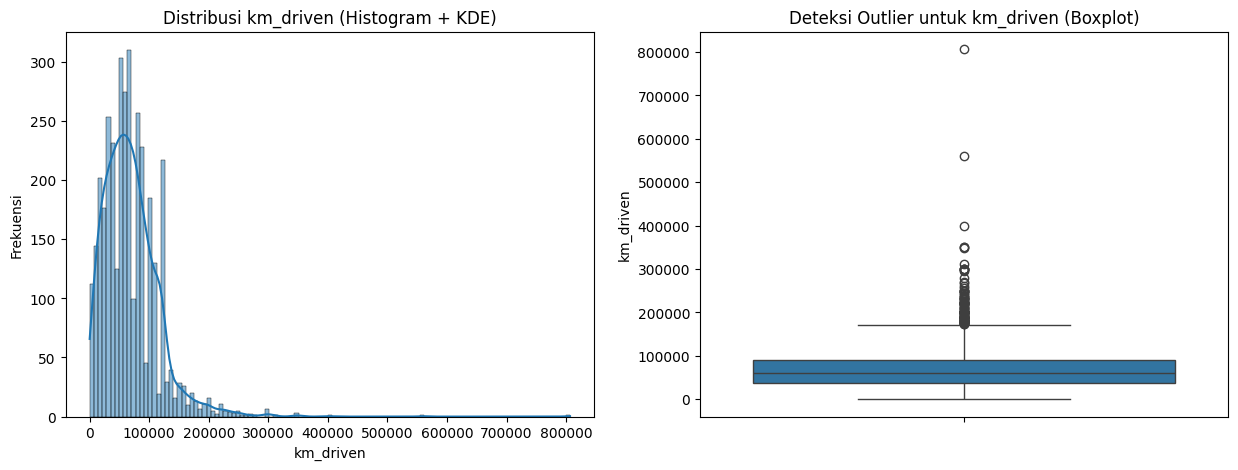

--- Analisis Univariat untuk Kolom Kategorikal


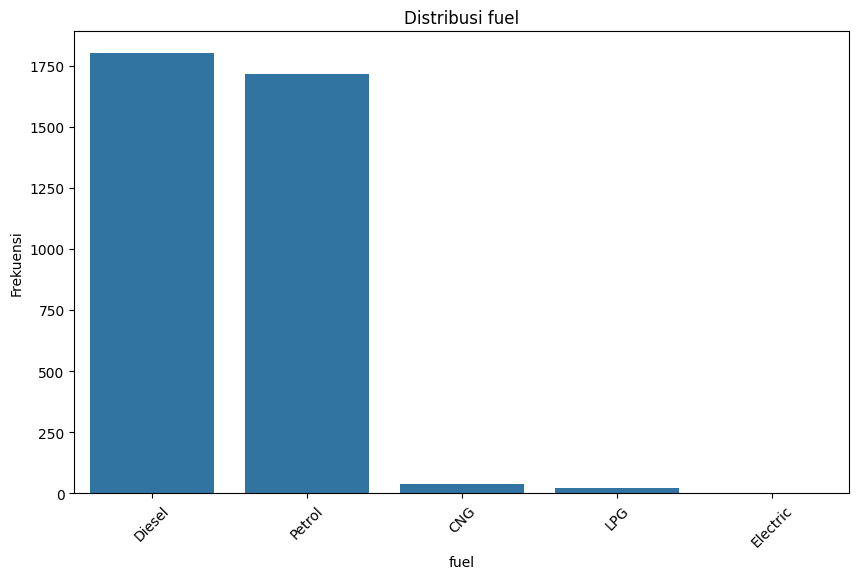

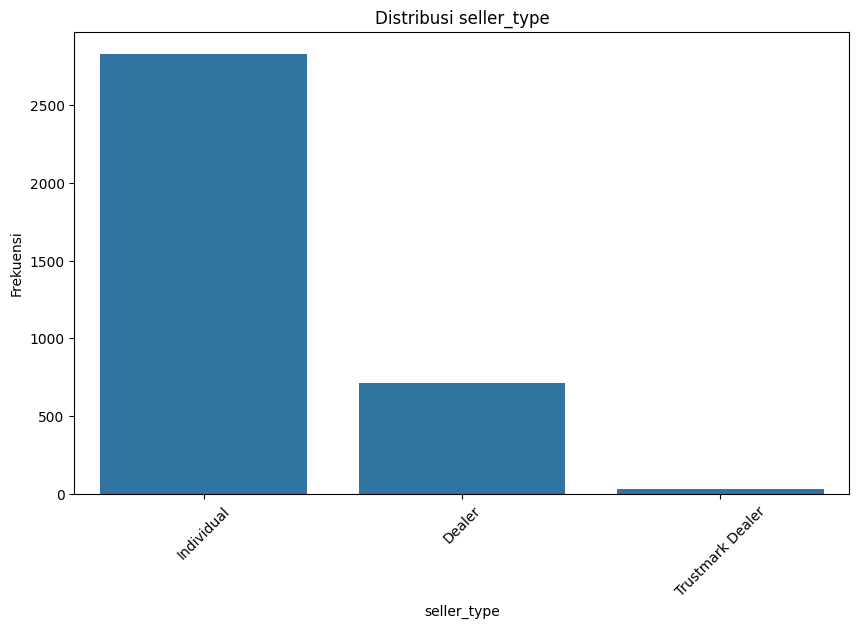

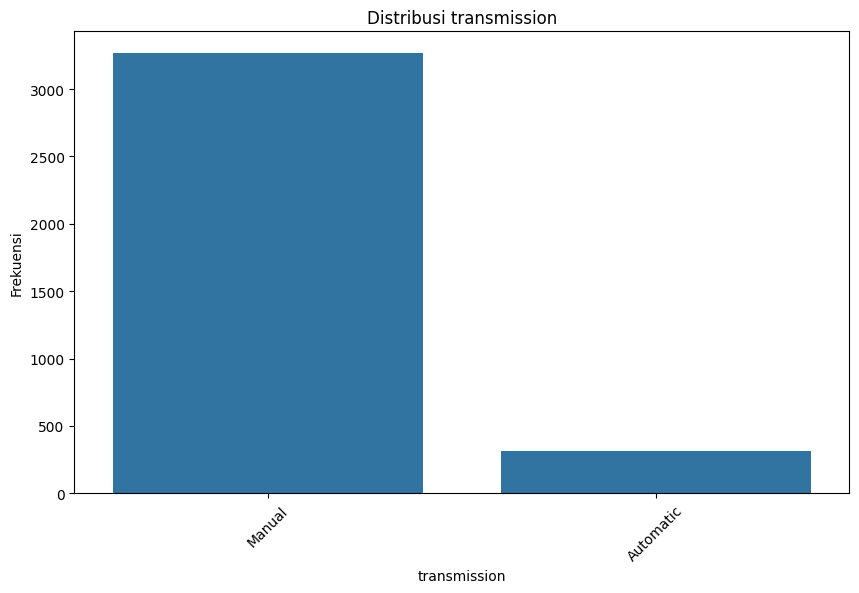

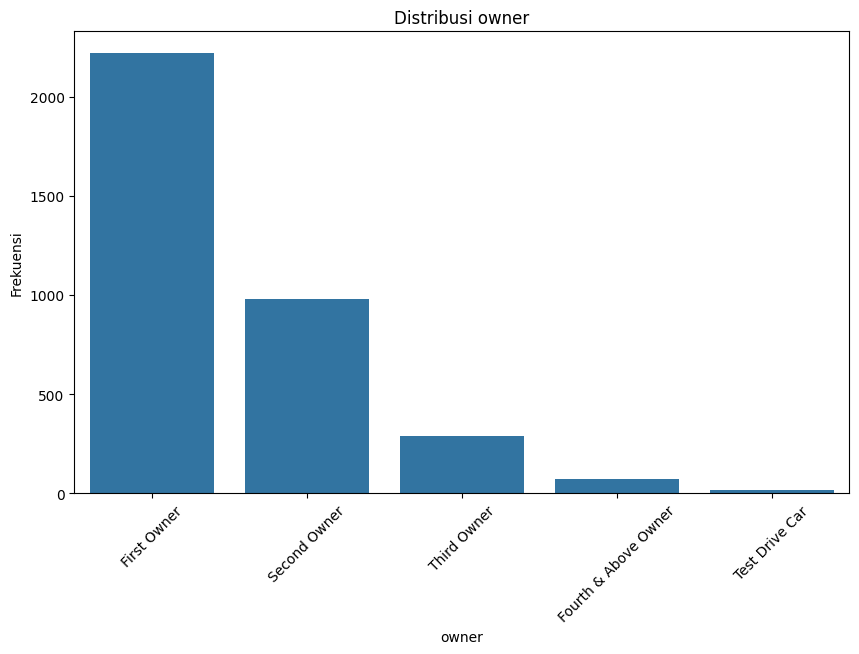

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom_numerik = df.select_dtypes(include='number')
kolom_kategorikal = df.select_dtypes(include='object')

print("--- Analisis Univariat untuk Kolom Numerik")
for kolom in kolom_numerik:
  plt.figure(figsize=(15,5))

  plt.subplot(1,2,1)
  sns.histplot(df[kolom], kde=True)
  plt.title(f'Distribusi {kolom} (Histogram + KDE)')
  plt.xlabel(kolom)
  plt.ylabel('Frekuensi')

  plt.subplot(1,2,2)
  sns.boxplot(y=df[kolom])
  plt.title(f'Deteksi Outlier untuk {kolom} (Boxplot)')
  plt.ylabel(kolom)
  plt.show()

print("--- Analisis Univariat untuk Kolom Kategorikal")
for kolom in kolom_kategorikal:
  if kolom == 'name':
    continue      # name punya 1.491 nilai unik, dianalisis terpisah di bawah
  plt.figure(figsize=(10,6))
  sns.countplot(x=df[kolom], order=df[kolom].value_counts().index)
  plt.title(f'Distribusi {kolom}')
  plt.xlabel(kolom)
  plt.ylabel('Frekuensi')
  plt.xticks(rotation=45)
  plt.show()

Kolom `name` memiliki 1.491 nilai unik, sehingga `countplot` biasa akan menghasilkan ribuan batang yang tidak terbaca.
Karena itu `name` dianalisis dengan dua cara: **15 nama terbanyak** dan **histogram frekuensi kemunculan**.

Jumlah nama unik          : 1491
Nama yang hanya muncul 1x : 822 (55% dari nama unik)


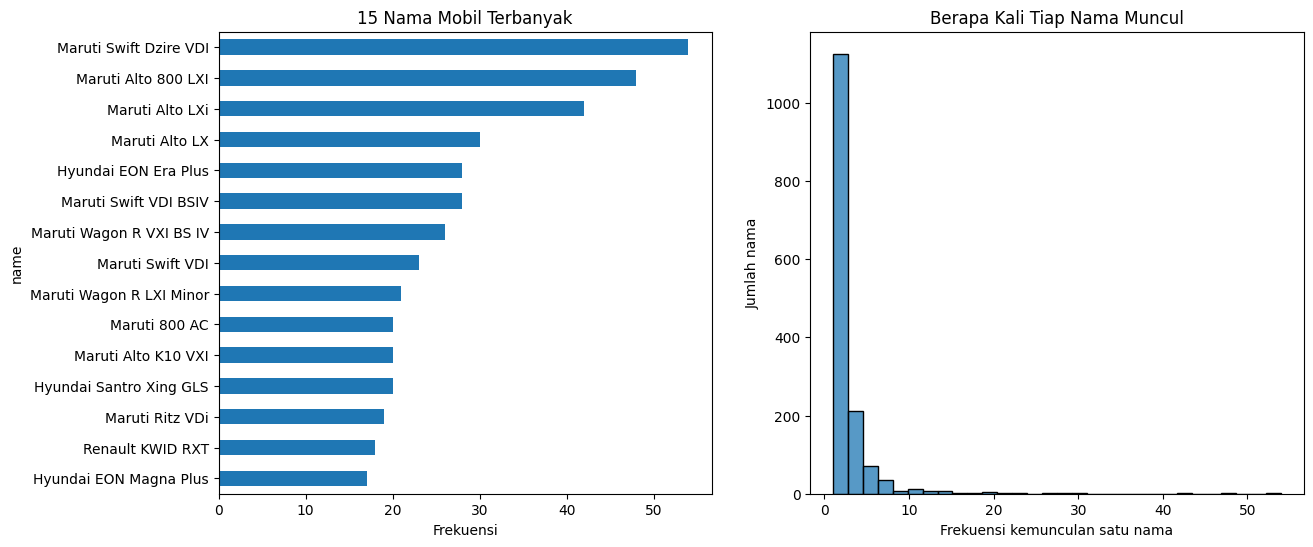

In [11]:
frek_nama = df['name'].value_counts()
print(f"Jumlah nama unik          : {len(frek_nama)}")
print(f"Nama yang hanya muncul 1x : {(frek_nama == 1).sum()} ({(frek_nama == 1).mean() * 100:.0f}% dari nama unik)")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
frek_nama.head(15).sort_values().plot(kind='barh')
plt.title('15 Nama Mobil Terbanyak')
plt.xlabel('Frekuensi')

plt.subplot(1, 2, 2)
sns.histplot(frek_nama, bins=30)
plt.title('Berapa Kali Tiap Nama Muncul')
plt.xlabel('Frekuensi kemunculan satu nama')
plt.ylabel('Jumlah nama')
plt.show()

Merek (kata pertama dari `name`) hanya memiliki sekitar 28 nilai unik, sehingga bisa divisualisasikan dengan jelas.
Kolom `brand` yang sebenarnya dibuat pada tahap Feature Engineering. Di sini kita memakai variabel sementara `brand_eda` agar `df` tidak berubah.

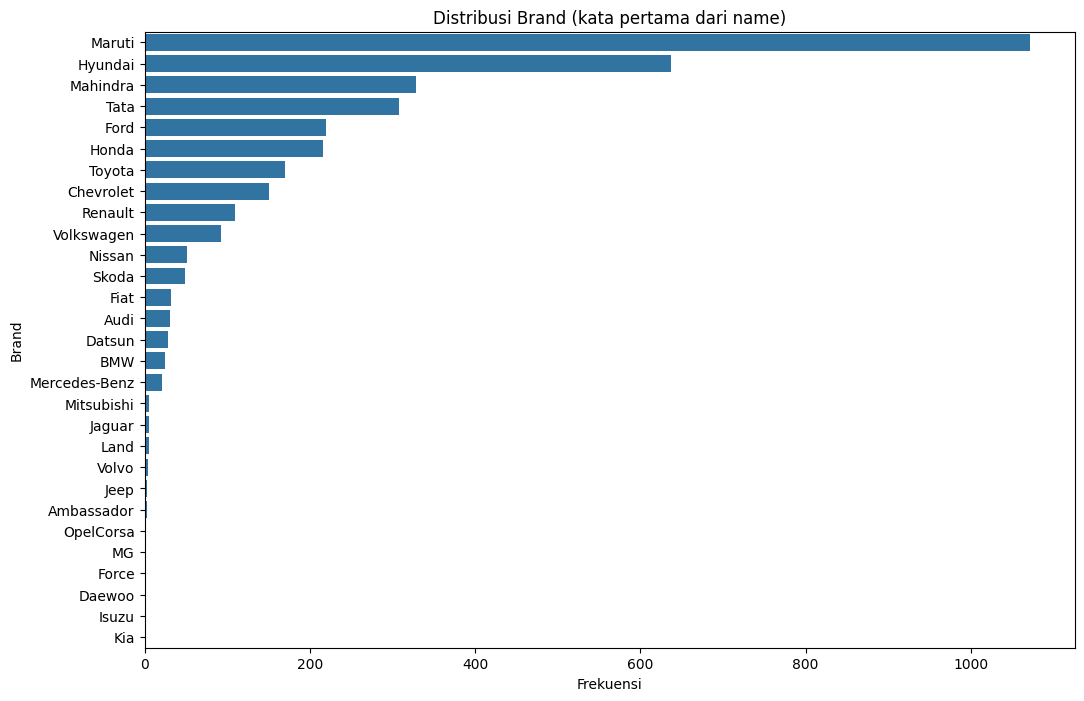

In [12]:
brand_eda = df['name'].str.split().str[0]

plt.figure(figsize=(12, 8))
sns.countplot(y=brand_eda, order=brand_eda.value_counts().index)
plt.title('Distribusi Brand (kata pertama dari name)')
plt.xlabel('Frekuensi')
plt.ylabel('Brand')
plt.show()

--- Heatmap Korelasi Antar Kolom Numerik ---


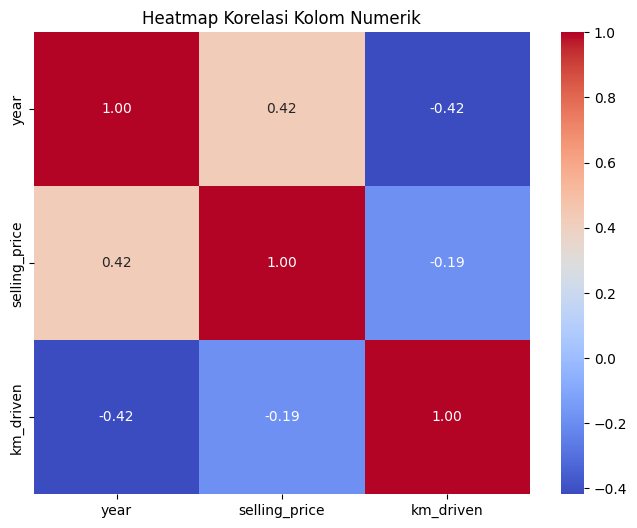

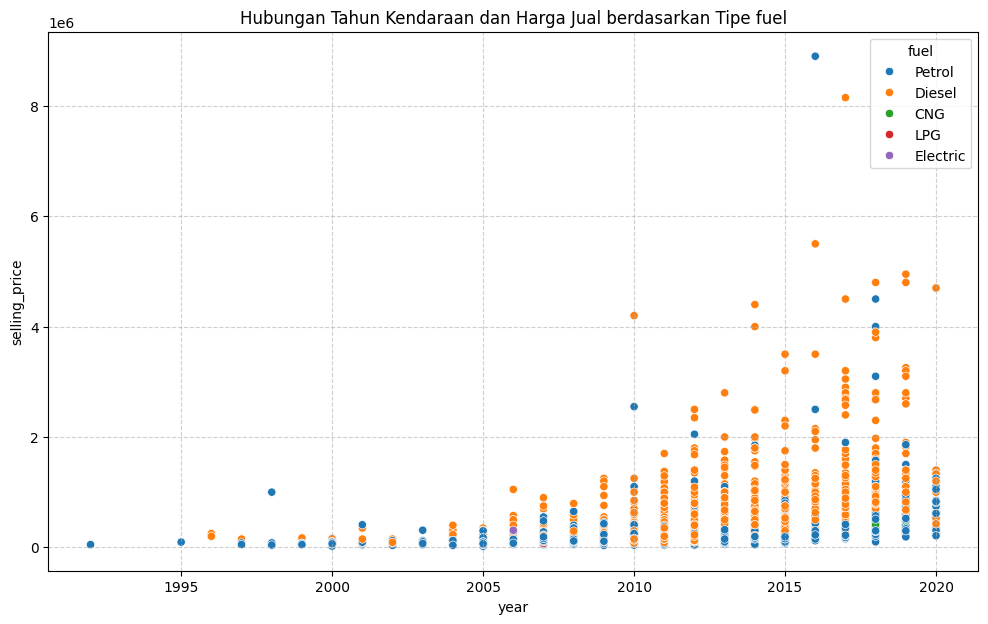

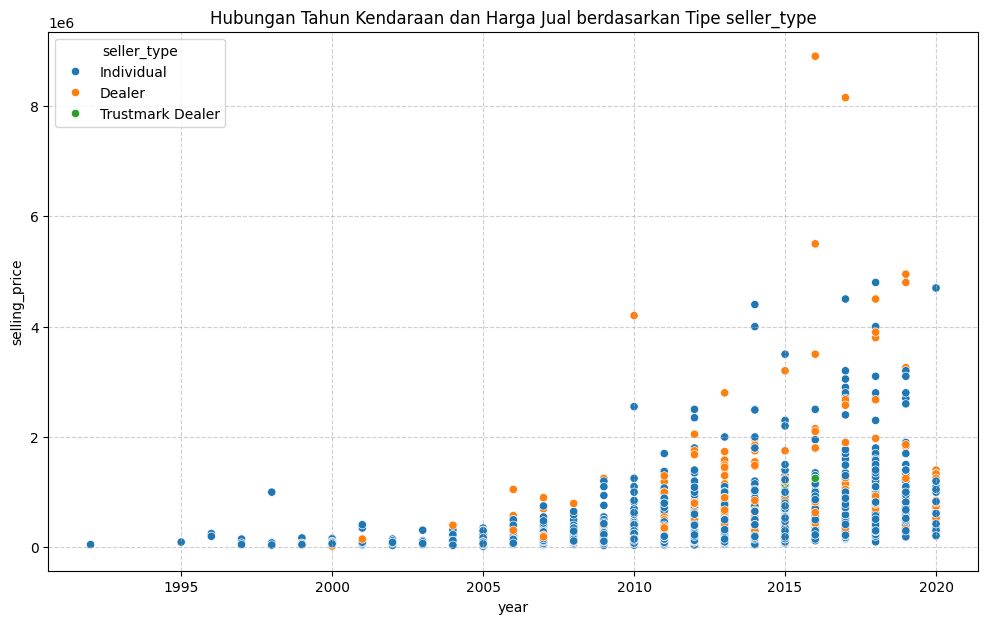

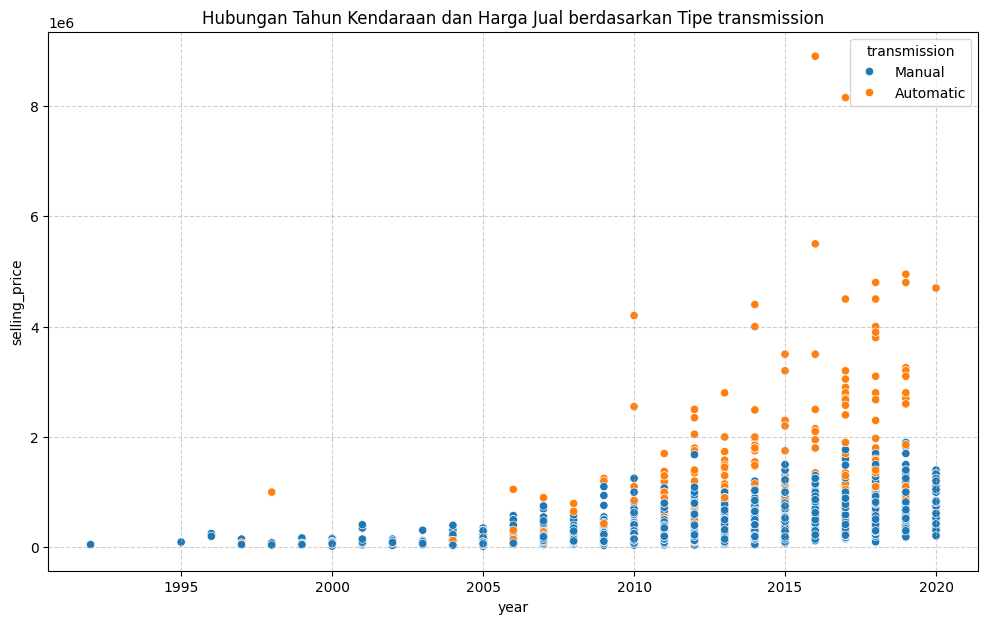

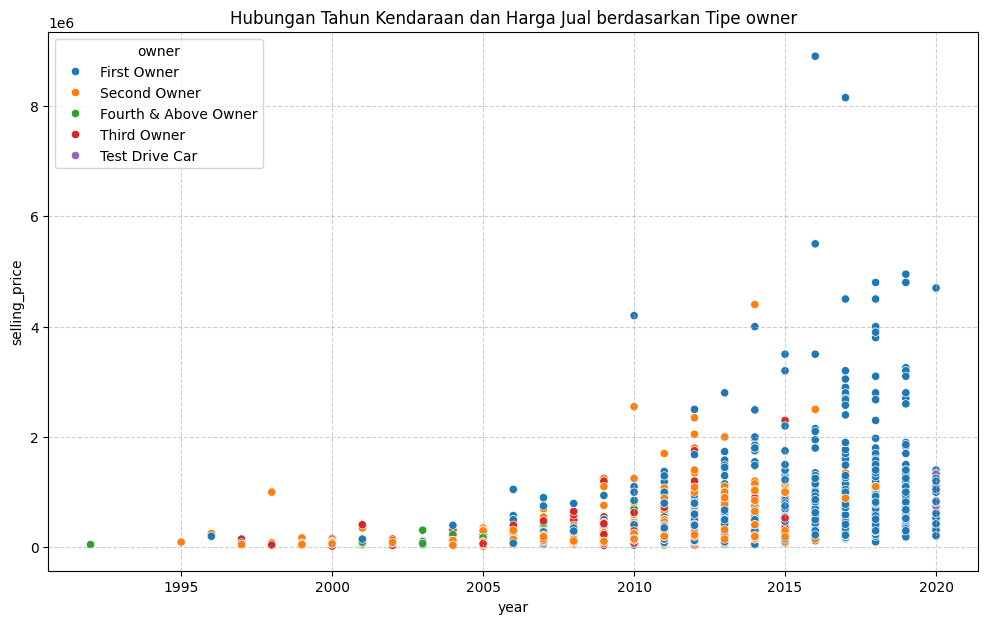

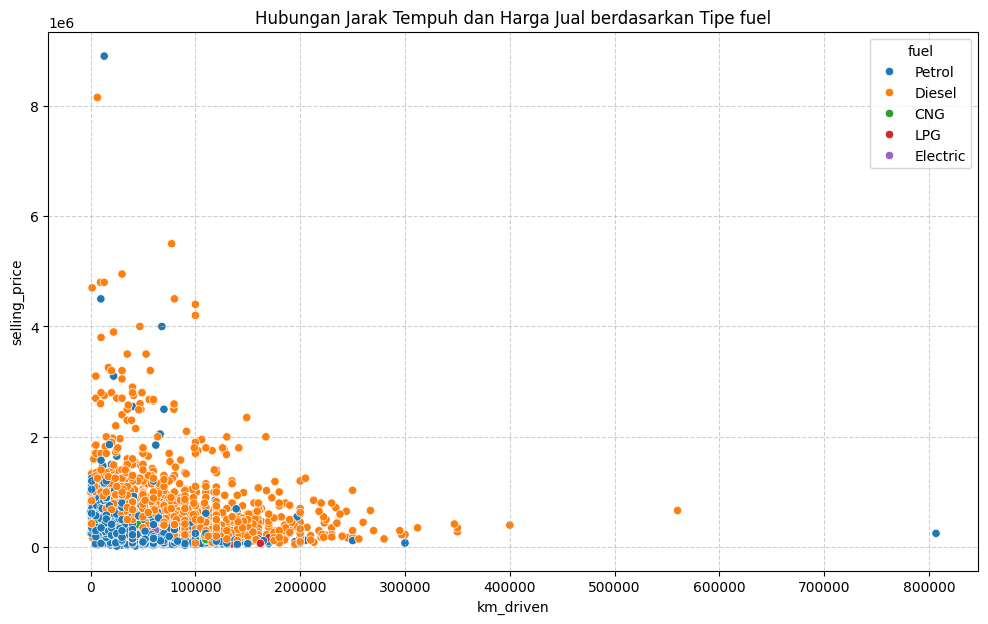

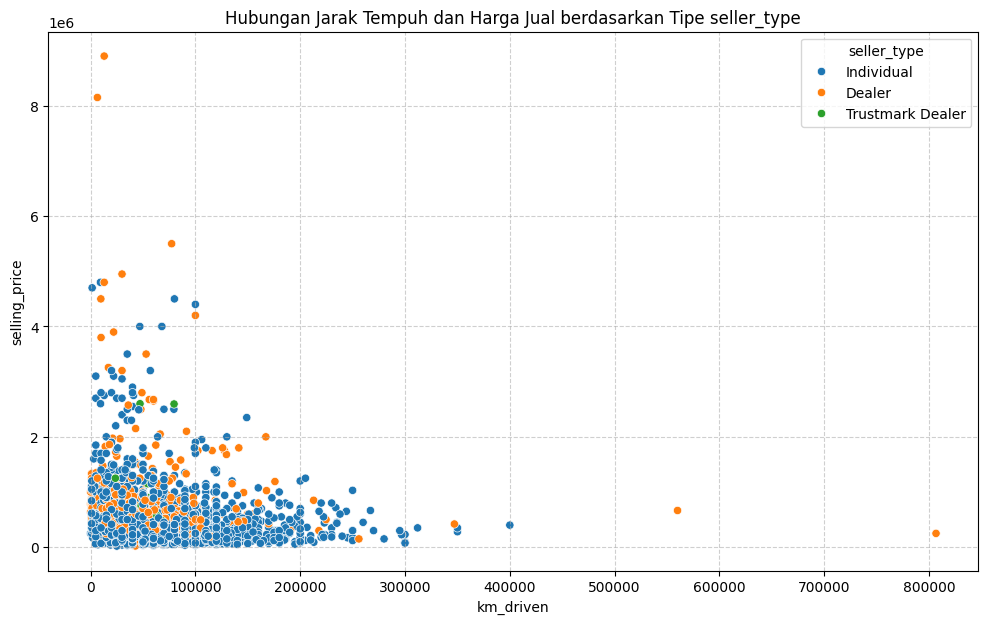

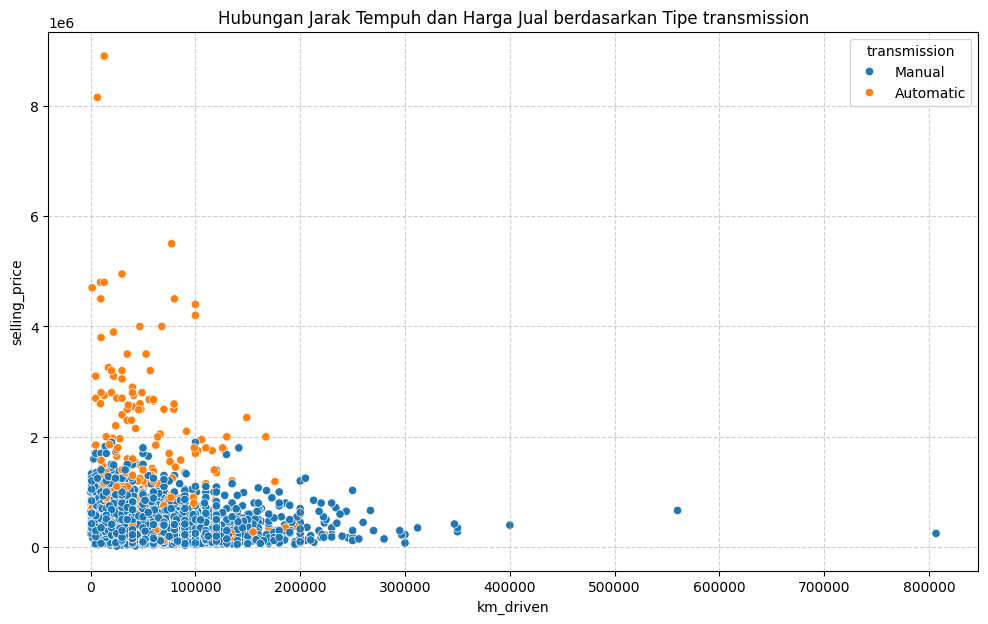

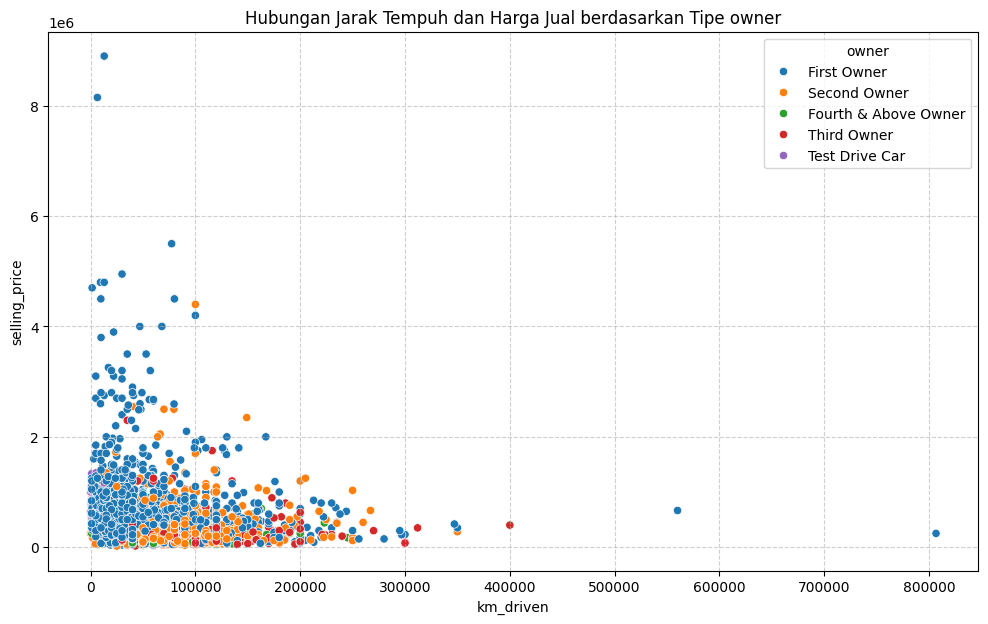

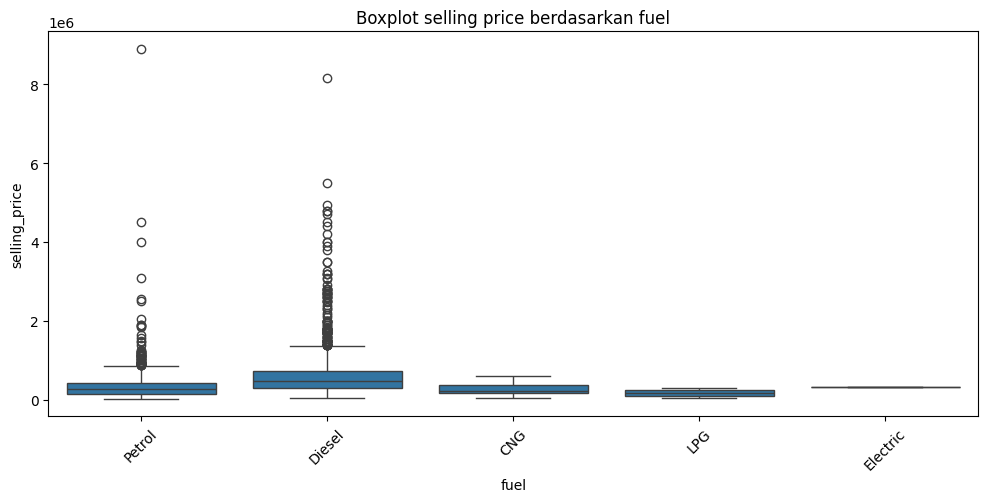

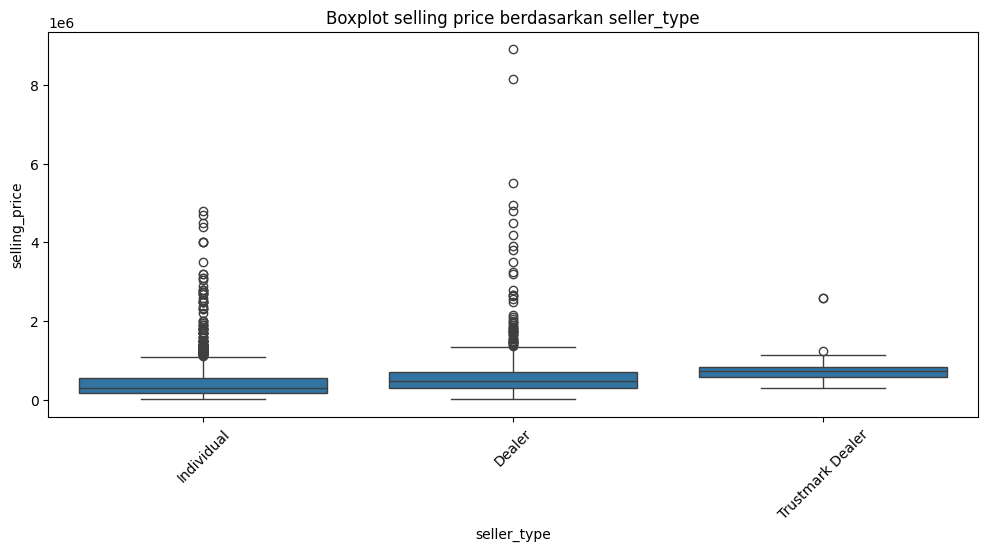

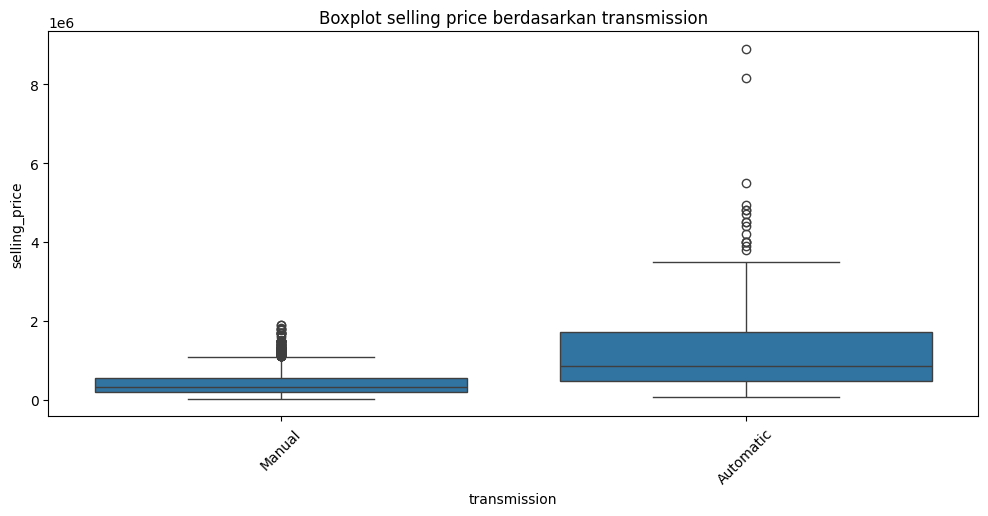

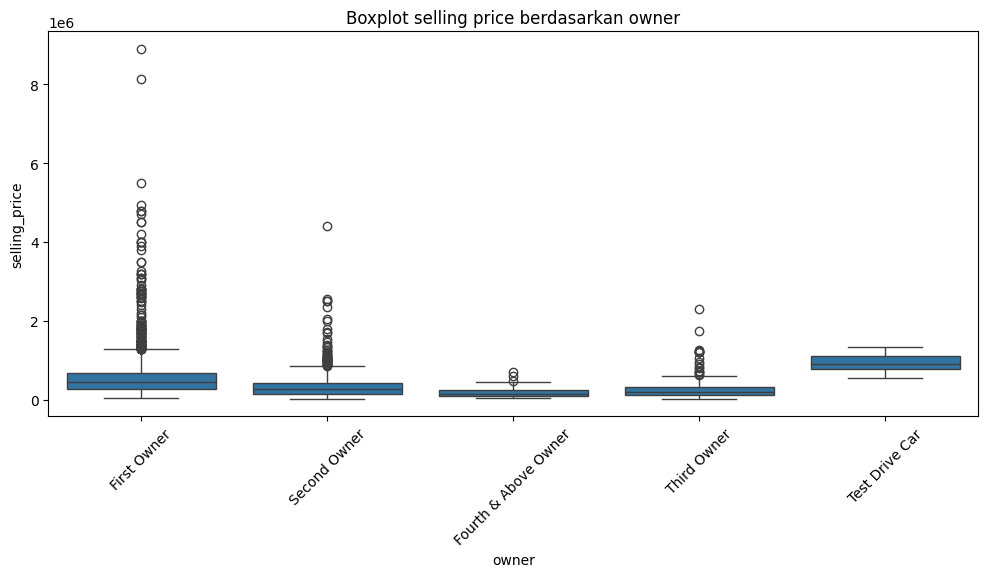

In [13]:
print("--- Heatmap Korelasi Antar Kolom Numerik ---")
plt.figure(figsize=(8, 6))
correlation_matrix = kolom_numerik.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Kolom Numerik')
plt.show()

for i in kolom_kategorikal:
  if(i == 'name'):
    continue
  plt.figure(figsize=(12, 7))
  sns.scatterplot(data= df, x = 'year', y='selling_price', hue=i)
  plt.title(f'Hubungan Tahun Kendaraan dan Harga Jual berdasarkan Tipe {i}')
  plt.xlabel('year')
  plt.ylabel('selling_price')
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()

for i in kolom_kategorikal:
  if(i == 'name'):
    continue
  plt.figure(figsize=(12, 7))
  sns.scatterplot(data= df, x = 'km_driven', y='selling_price', hue=i)
  plt.title(f'Hubungan Jarak Tempuh dan Harga Jual berdasarkan Tipe {i}')
  plt.xlabel('km_driven')
  plt.ylabel('selling_price')
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()

for kol_kategori in kolom_kategorikal:
  if(kol_kategori == 'name'):
    continue
  plt.figure(figsize=(12, 5))
  sns.boxplot(x=kol_kategori, y=df['selling_price'], data=df)
  plt.title(f'Boxplot selling price berdasarkan {kol_kategori}')
  plt.xlabel(kol_kategori)
  plt.ylabel('selling_price')
  plt.xticks(rotation=45)
  plt.show()

Kolom `name` dilewati pada scatter plot dan boxplot di atas karena terlalu banyak kategori (hasilnya tidak terbaca).
Sebagai gantinya, hubungan nama dengan harga dilihat melalui **brand**. Hanya brand dengan minimal 30 baris yang ditampilkan agar boxplot bermakna, diurutkan dari median harga terendah. Sumbu harga memakai skala log karena harga sangat timpang.

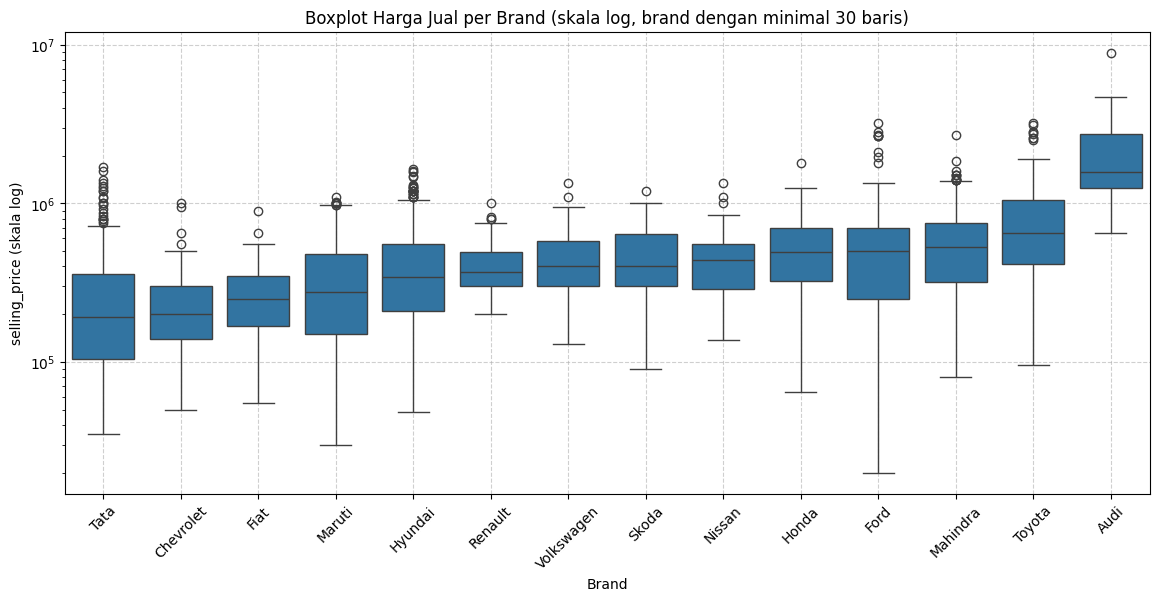

In [14]:
jumlah_brand = brand_eda.value_counts()
brand_cukup = jumlah_brand[jumlah_brand >= 30].index
data_brand = df[brand_eda.isin(brand_cukup)]
urutan = data_brand.groupby(brand_eda[brand_eda.isin(brand_cukup)])['selling_price'].median().sort_values().index

plt.figure(figsize=(14, 6))
sns.boxplot(x=brand_eda[brand_eda.isin(brand_cukup)], y=data_brand['selling_price'], order=urutan)
plt.yscale('log')
plt.title('Boxplot Harga Jual per Brand (skala log, brand dengan minimal 30 baris)')
plt.xlabel('Brand')
plt.ylabel('selling_price (skala log)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

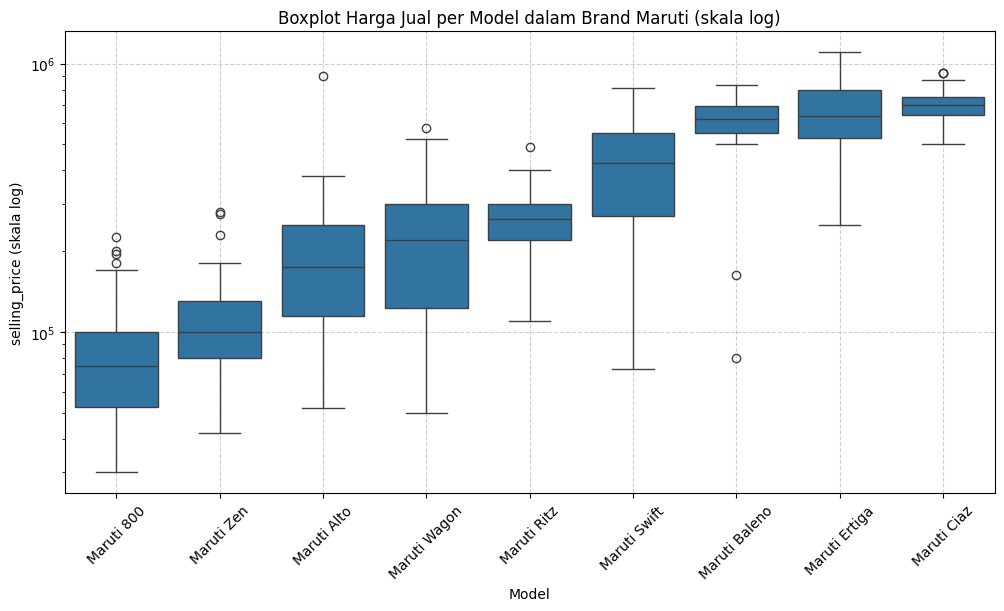

In [15]:
model_eda = df['name'].str.title().str.split().str[0:2].str.join(' ')    # variabel sementara untuk EDA
brand_teratas = brand_eda.value_counts().index[0]

data_sub = df[brand_eda == brand_teratas]
model_sub = model_eda[brand_eda == brand_teratas]
jumlah_model = model_sub.value_counts()
model_cukup = jumlah_model[jumlah_model >= 30].index
urutan_model = data_sub[model_sub.isin(model_cukup)].groupby(model_sub[model_sub.isin(model_cukup)])['selling_price'].median().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(x=model_sub[model_sub.isin(model_cukup)], y=data_sub.loc[model_sub.isin(model_cukup), 'selling_price'], order=urutan_model)
plt.yscale('log')
plt.title(f'Boxplot Harga Jual per Model dalam Brand {brand_teratas} (skala log)')
plt.xlabel('Model')
plt.ylabel('selling_price (skala log)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Temuan EDA yang dipakai pada tahap berikutnya**
- `selling_price` sangat condong ke kanan (mobil mewah jauh lebih mahal), sehingga nanti harga diubah ke skala log.
- `year` berkorelasi kuat dengan harga, jadi diubah menjadi umur kendaraan.
- `name` memiliki 1.491 nilai unik sehingga tidak bisa di-encode langsung. Nama akan dipecah menjadi `brand` dan `model`.
- Merek berpengaruh pada harga, dan **model dalam satu brand yang sama pun harganya sangat berbeda**, sehingga keduanya dipakai.

## Tahap 3 - Feature Engineering

1. **Berbasis waktu:** `year` diubah menjadi `vehicle_age` (umur kendaraan saat ini).
2. **Nama mobil:** dipecah menjadi `brand` (merek) dan `model` (merek + seri).
3. **Owner:** diubah menjadi angka berurutan 0 sampai 4, karena jumlah pemilik memiliki urutan.

In [16]:
from datetime import date

df['vehicle_age'] = date.today().year - df['year']

In [17]:
kata = df['name'].str.title().str.split()   # samakan huruf besar-kecil (mis. EcoSport = Ecosport)
df['brand'] = kata.str[0].replace({'Land': 'Land Rover'})
df['model'] = kata.str[0:2].str.join(' ')          # contoh: 'Maruti Swift'

In [18]:
df['owner'] = df['owner'].map({'Test Drive Car': 0, 'First Owner': 1, 'Second Owner': 2,
                               'Third Owner': 3, 'Fourth & Above Owner': 4})
df = df.drop(columns=['name', 'year'])

x = df.drop(columns='selling_price')

## Tahap 4 - Pembagian Data Latih dan Uji

Harga (`y`) diubah ke skala log dengan `np.log1p` karena sebarannya sangat timpang. Data dibagi 80% latih dan 20% uji.

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split

y = np.log1p(df['selling_price'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

**Penggabungan kategori langka.** `brand` dan `model` yang muncul **kurang dari 5 kali di data latih** digabung menjadi `'Lainnya'`.

Alasannya: kategori yang hanya punya 1 sampai 4 contoh terlalu sedikit untuk dipelajari model, dan masing-masing akan menambah satu kolom baru saat `get_dummies`. Angka 5 adalah batas praktis yang dipilih agar kolom berkurang jauh tanpa membuang informasi model yang populer

Daftar kategori yang sering dihitung **hanya dari data latih**, lalu diterapkan ke data uji (mencegah kebocoran data). Baris `'Lainnya'` tidak dibuang dan tetap ikut dalam pemodelan.

In [20]:
ambang = 5      # batas minimal kemunculan

for kolom in ['brand', 'model']:
    sering = x_train[kolom].value_counts()
    sering = sering[sering >= ambang].index
    x_train[kolom] = x_train[kolom].where(x_train[kolom].isin(sering), 'Lainnya')
    x_test[kolom]  = x_test[kolom].where(x_test[kolom].isin(sering), 'Lainnya')

In [21]:
display(x_train[x_train['model'] == 'Lainnya'])

,km_driven,fuel,seller_type,transmission,owner,vehicle_age,brand,model
2510,90000,Petrol,Individual,Manual,2,10,Tata,Lainnya
195,55000,Petrol,Dealer,Manual,1,13,Renault,Lainnya
842,25000,Diesel,Individual,Automatic,1,8,Audi,Lainnya
3276,30000,Petrol,Individual,Manual,1,11,Tata,Lainnya
905,80000,Diesel,Individual,Manual,2,14,Tata,Lainnya
...,...,...,...,...,...,...,...,...
3461,116000,Diesel,Individual,Manual,2,24,Skoda,Lainnya
2435,120000,Diesel,Individual,Manual,4,24,Lainnya,Lainnya
1899,15000,Diesel,Individual,Manual,1,7,Nissan,Lainnya
2300,30000,Diesel,Individual,Manual,2,12,Hyundai,Lainnya


## Tahap 5 - Encoding, Scaling, dan Pemodelan

In [22]:
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

x_train = pd.get_dummies(x_train, columns=['fuel','seller_type','transmission','brand','model'], drop_first=True, dtype=int)
x_test  = pd.get_dummies(x_test,  columns=['fuel','seller_type','transmission','brand','model'], drop_first=True, dtype=int)
x_test  = x_test.reindex(columns=x_train.columns, fill_value=0)

scaler = StandardScaler()
x_train[['km_driven', 'vehicle_age']] = scaler.fit_transform(x_train[['km_driven', 'vehicle_age']])
x_test[['km_driven', 'vehicle_age']]  = scaler.transform(x_test[['km_driven', 'vehicle_age']])

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

### Tahap 6 - Evaluasi

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

print("Jumlah kolom:", x_train.shape[1])
print("CV R2 baseline:", round(cross_val_score(DummyRegressor(), x_train, y_train, cv=5, scoring='r2').mean(), 4))
print("CV R2 model   :", round(cross_val_score(LinearRegression(), x_train, y_train, cv=5, scoring='r2').mean(), 4))

pred_train = model.predict(x_train)
pred_test  = model.predict(x_test)
print("R2 train:", round(r2_score(y_train, pred_train), 4), "| R2 test:", round(r2_score(y_test, pred_test), 4))

asli     = np.expm1(y_test)       # kembalikan dari log ke harga asli (rupee)
prediksi = np.expm1(pred_test)
print("R2   (skala asli):", round(r2_score(asli, prediksi), 4))
print("MAE  (rupee)     :", f"{mean_absolute_error(asli, prediksi):,.0f}")
print("RMSE (rupee)     :", f"{np.sqrt(mean_squared_error(asli, prediksi)):,.0f}")
print("Prediksi negatif :", (prediksi < 0).sum())

Jumlah kolom: 130
CV R2 baseline: -0.0009
CV R2 model   : 0.8836
R2 train: 0.9002 | R2 test: 0.8865
R2   (skala asli): 0.7931
MAE  (rupee)     : 96,716
RMSE (rupee)     : 258,167
Prediksi negatif : 0


## Tahap 7 - Visualisasi Hasil Regresi

### 7.1 Aktual vs Prediksi

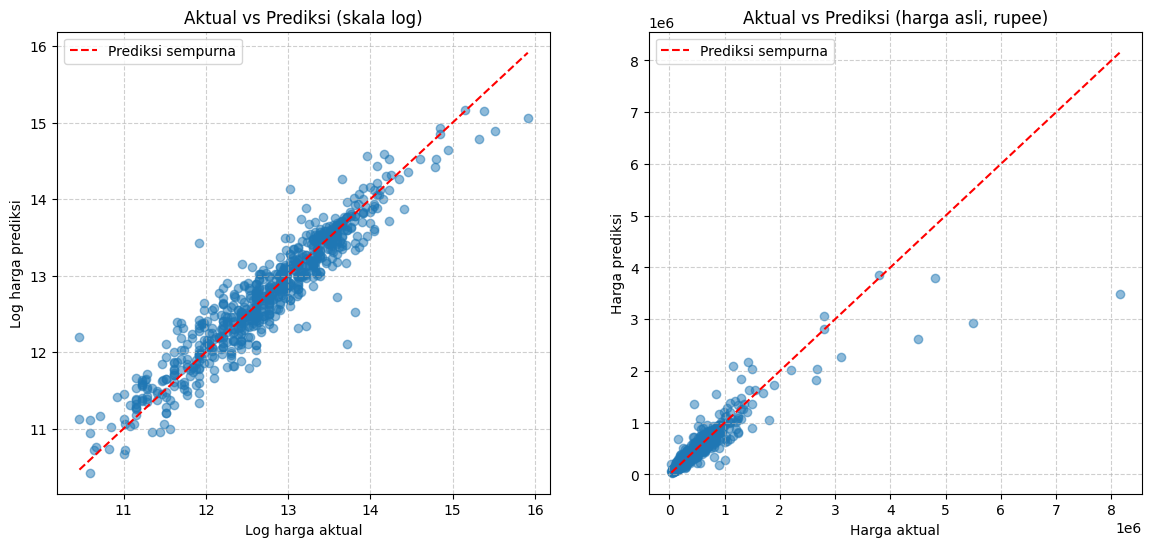

In [24]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, pred_test, alpha=0.5)
batas = [y_test.min(), y_test.max()]
plt.plot(batas, batas, color='red', linestyle='--', label='Prediksi sempurna')
plt.title('Aktual vs Prediksi (skala log)')
plt.xlabel('Log harga aktual')
plt.ylabel('Log harga prediksi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.scatter(asli, prediksi, alpha=0.5)
batas = [asli.min(), asli.max()]
plt.plot(batas, batas, color='red', linestyle='--', label='Prediksi sempurna')
plt.title('Aktual vs Prediksi (harga asli, rupee)')
plt.xlabel('Harga aktual')
plt.ylabel('Harga prediksi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 7.2 Analisis Residual

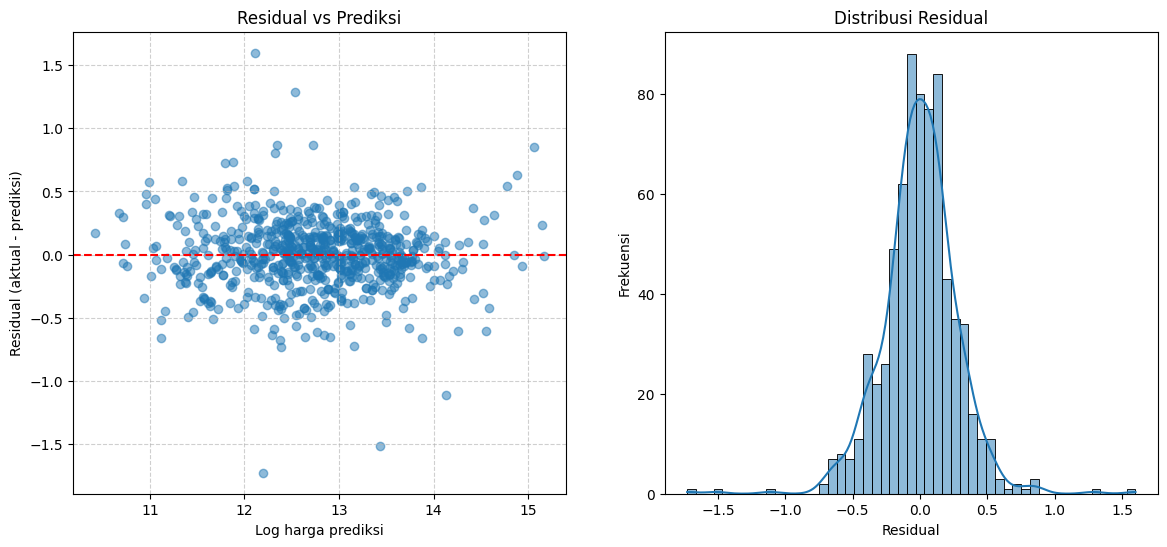

In [25]:
residual = y_test - pred_test

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(pred_test, residual, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual vs Prediksi')
plt.xlabel('Log harga prediksi')
plt.ylabel('Residual (aktual - prediksi)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.histplot(residual, kde=True)
plt.title('Distribusi Residual')
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.show()

### 7.3 Garis Regresi: Umur Kendaraan vs Harga
Garis ini adalah regresi sederhana satu fitur, hanya untuk menggambarkan tren utama (makin tua mobil, makin murah).
Model utama kita memakai banyak fitur sekaligus.

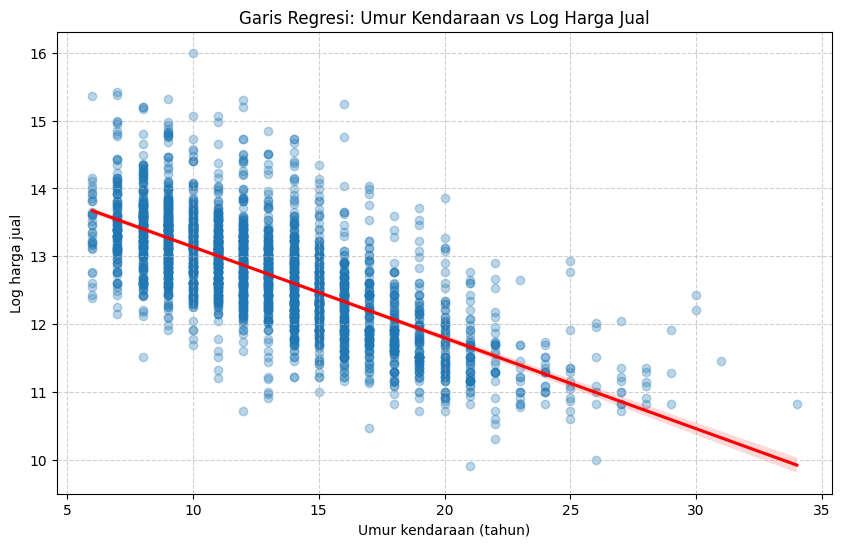

In [26]:
data_latih = df.loc[x_train.index]      # data latih dengan nilai asli (belum di-scaling)

plt.figure(figsize=(10, 6))
sns.regplot(x=data_latih['vehicle_age'], y=np.log1p(data_latih['selling_price']),
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Garis Regresi: Umur Kendaraan vs Log Harga Jual')
plt.xlabel('Umur kendaraan (tahun)')
plt.ylabel('Log harga jual')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 7.4 Pengaruh Fitur terhadap Harga
Target berupa log harga, sehingga koefisien dibaca sebagai **persen perubahan harga**: `(e^koefisien - 1) x 100`.
Dummy `brand` dan `model` tidak ditampilkan di grafik ini, melainkan di bagian 7.5 dengan cara yang lebih tepat.
`fuel_*` dibandingkan dengan CNG, dan `seller_type_*` dibandingkan dengan Dealer.

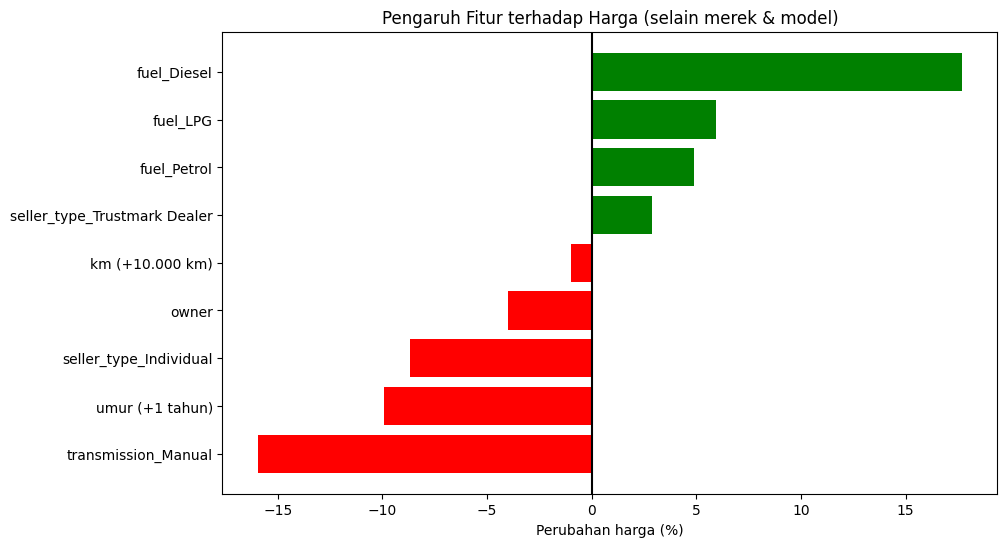

In [27]:
koef = pd.Series(model.coef_, index=x_train.columns)

# kembalikan koefisien fitur ber-scaling ke satuan asli
koef['vehicle_age'] = koef['vehicle_age'] / scaler.scale_[1]            # per 1 tahun
koef['km_driven']   = koef['km_driven'] * 10000 / scaler.scale_[0]      # per 10.000 km

# tampilkan fitur yang mudah ditafsirkan (dummy brand/model disisihkan)
fitur = [k for k in koef.index if not k.startswith(('brand_', 'model_'))]
persen = ((np.exp(koef[fitur]) - 1) * 100).sort_values()
persen.index = persen.index.str.replace('vehicle_age', 'umur (+1 tahun)').str.replace('km_driven', 'km (+10.000 km)')

plt.figure(figsize=(10, 6))
warna = ['green' if v > 0 else 'red' for v in persen.values]
plt.barh(persen.index, persen.values, color=warna)
plt.axvline(0, color='black')
plt.title('Pengaruh Fitur terhadap Harga (selain merek & model)')
plt.xlabel('Perubahan harga (%)')
plt.show()